# Module 1 — ML Model Training (Carbon Credit Prediction)
**Project:** IoT and ML Based Carbon Credit Estimation and Monitoring System for Agriculture and Industry

**Input:** `cleaned_carbon_credit_dataset.csv` (output of the Data Cleaning + EDA notebook)
**Goal:** Train a model that predicts `Carbon_Credit_Score` from live sensor readings + farming context, so it can later be applied to real ESP32/Firebase data for real-time prediction.

**Models compared:** Linear Regression (simple baseline) vs Random Forest Regressor (usually more accurate, still easy to explain).


## 0. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


## Step 1: Load Cleaned Dataset

In [5]:
df = pd.read_csv("D:/GreenAgri/GreenAgri_CarbonCredit_Estimator/data/processed/cleaned_carbon_credit_dataset.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 500 rows x 16 columns


,Record_ID,Date,Location,Crop_Type,Farming_Practice,Soil_Moisture_%,Temperature_C,Humidity_%,Soil_pH,Gas_Sensor_ppm,Energy_Consumption_kWh,Carbon_Emission_kgCO2,Carbon_Saved_kgCO2,Carbon_Credit_Score,Month,Emission_Category
0,REC0111,2024-04-20,Amravati_Field_2,Sugarcane,Zero Tillage,15.81,31.27,57.14,6.30,356.47,146.06,39.26,110.74,0.1107,April,Low
1,REC0245,2024-09-01,Wardha_Field_1,Cotton,Zero Tillage,23.00,30.59,50.26,5.85,529.38,18.82,15.01,134.99,0.1350,September,Low
2,REC0335,2024-11-30,Chandrapur_Farm_C,Wheat,Organic Farming,44.75,27.83,62.23,6.07,471.23,110.26,-6.07,156.07,0.1561,November,Low
3,REC0440,2025-03-15,Amravati_Field_2,Sugarcane,No-Till,34.44,25.18,71.02,6.57,271.47,104.30,-13.45,163.45,0.1634,March,Low
4,REC0234,2024-08-21,Bhandara_Field_4,Cotton,Organic Farming,28.48,19.49,98.70,6.29,471.41,84.81,6.03,143.97,0.1440,August,Low


## Step 2: Select Features and Target

**Target:** `Carbon_Credit_Score`

**Features used (raw sensor inputs + farming context only):**
- `Soil_Moisture_%`, `Temperature_C`, `Humidity_%`, `Soil_pH`, `Gas_Sensor_ppm`, `Energy_Consumption_kWh`
- `Farming_Practice`, `Crop_Type` (categorical — will be one-hot encoded)

**Columns deliberately EXCLUDED (data leakage):**
- `Carbon_Emission_kgCO2` and `Carbon_Saved_kgCO2` — these are used to directly *compute* `Carbon_Credit_Score`, so including them would let the model "cheat" instead of learning from sensor data.
- `Emission_Category` — also derived directly from `Carbon_Emission_kgCO2`, same leakage issue.
- `Record_ID`, `Date`, `Location`, `Month` — identifiers/metadata, not predictive sensor signals.


In [6]:
feature_cols = [
    "Soil_Moisture_%", "Temperature_C", "Humidity_%", "Soil_pH",
    "Gas_Sensor_ppm", "Energy_Consumption_kWh",
    "Farming_Practice", "Crop_Type"
]
target_col = "Carbon_Credit_Score"

X = df[feature_cols]
y = df[target_col]

numeric_features = ["Soil_Moisture_%", "Temperature_C", "Humidity_%", "Soil_pH",
                     "Gas_Sensor_ppm", "Energy_Consumption_kWh"]
categorical_features = ["Farming_Practice", "Crop_Type"]

print("Features:", feature_cols)
print("Target:", target_col)
X.head()


Features: ['Soil_Moisture_%', 'Temperature_C', 'Humidity_%', 'Soil_pH', 'Gas_Sensor_ppm', 'Energy_Consumption_kWh', 'Farming_Practice', 'Crop_Type']
Target: Carbon_Credit_Score


,Soil_Moisture_%,Temperature_C,Humidity_%,Soil_pH,Gas_Sensor_ppm,Energy_Consumption_kWh,Farming_Practice,Crop_Type
0,15.81,31.27,57.14,6.30,356.47,146.06,Zero Tillage,Sugarcane
1,23.00,30.59,50.26,5.85,529.38,18.82,Zero Tillage,Cotton
2,44.75,27.83,62.23,6.07,471.23,110.26,Organic Farming,Wheat
3,34.44,25.18,71.02,6.57,271.47,104.30,No-Till,Sugarcane
4,28.48,19.49,98.70,6.29,471.41,84.81,Organic Farming,Cotton


## Step 3: Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")


Train size: 400 rows
Test size:  100 rows


## Step 4: Preprocessing Pipeline

Numeric columns are passed through as-is; categorical columns (`Farming_Practice`, `Crop_Type`) are one-hot encoded. Wrapping this in a `ColumnTransformer` + `Pipeline` means the exact same preprocessing is automatically applied to any new data later (e.g. live Firebase sensor readings) — no manual re-encoding needed at prediction time.


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


## Step 5: Train Model 1 — Linear Regression

In [9]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("Linear Regression trained.")


Linear Regression trained.


## Step 6: Train Model 2 — Random Forest Regressor

In [10]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest trained.")


Random Forest trained.


## Step 7: Evaluate Both Models

In [11]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}\n")
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []
results.append(evaluate(y_test, y_pred_lr, "Linear Regression"))
results.append(evaluate(y_test, y_pred_rf, "Random Forest"))

results_df = pd.DataFrame(results)
results_df


--- Linear Regression ---
MAE  : 0.0094
RMSE : 0.0128
R2   : 0.0765

--- Random Forest ---
MAE  : 0.0093
RMSE : 0.0125
R2   : 0.1158



,Model,MAE,RMSE,R2
0,Linear Regression,0.009370,0.012781,0.076454
1,Random Forest,0.009301,0.012506,0.115800


## Step 8: Compare Models Visually

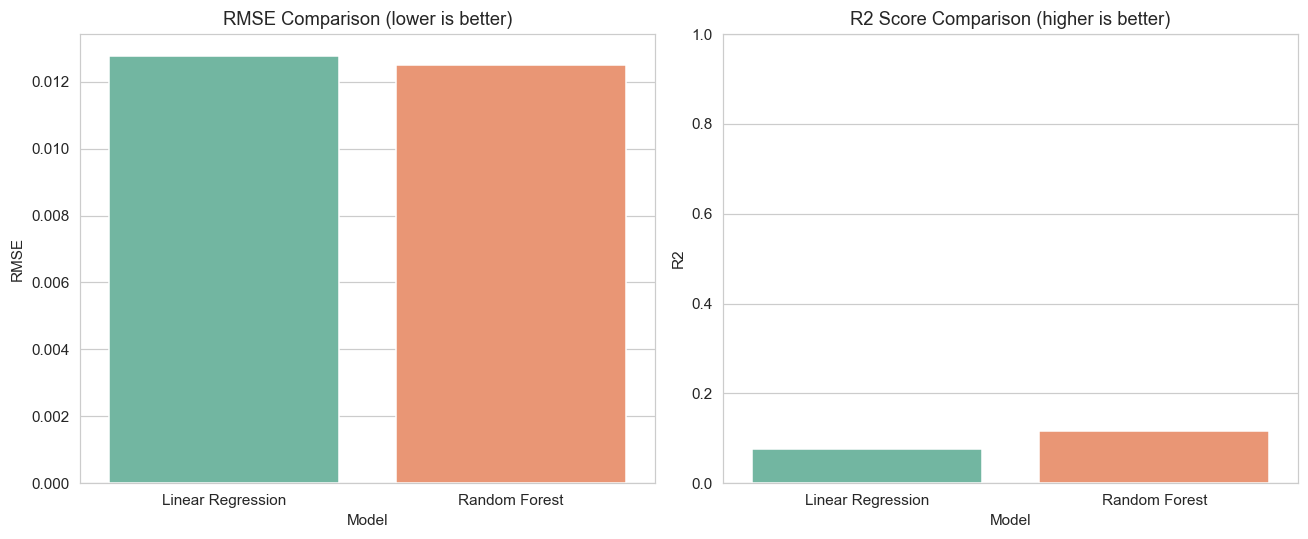

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=results_df, x="Model", y="RMSE", hue="Model", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("RMSE Comparison (lower is better)")

sns.barplot(data=results_df, x="Model", y="R2", hue="Model", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("R2 Score Comparison (higher is better)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()


## Step 9: Actual vs Predicted (Random Forest)

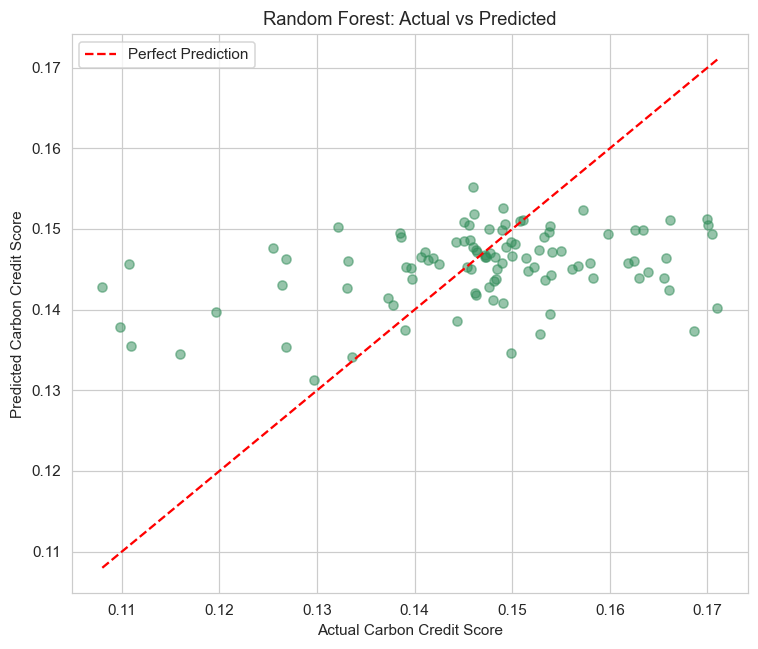

In [13]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="seagreen")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect Prediction")
plt.xlabel("Actual Carbon Credit Score")
plt.ylabel("Predicted Carbon Credit Score")
plt.title("Random Forest: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted_rf.png")
plt.show()


## Step 10: Feature Importance (Random Forest)

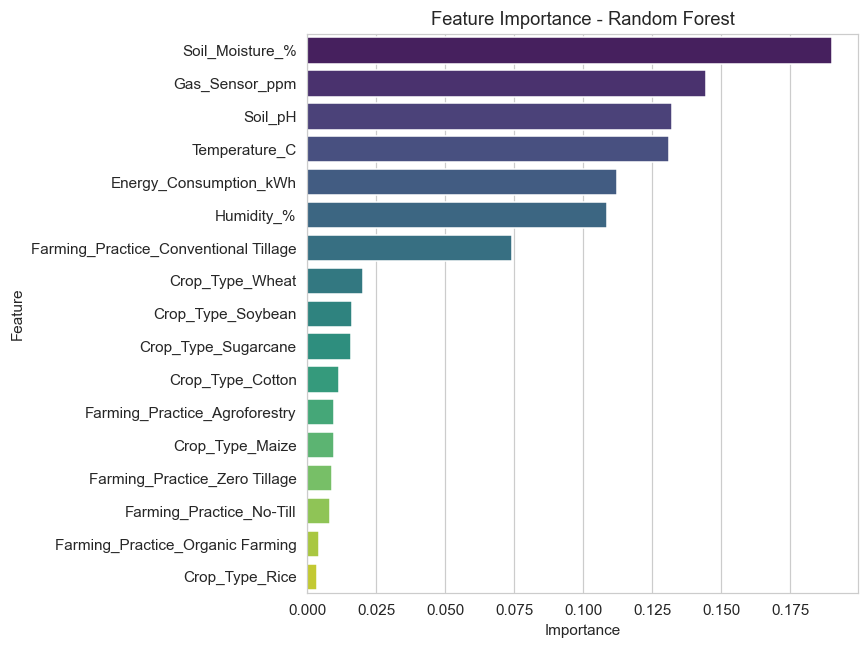

,Feature,Importance
0,Soil_Moisture_%,0.190023
4,Gas_Sensor_ppm,0.144359
3,Soil_pH,0.132219
1,Temperature_C,0.131020
5,Energy_Consumption_kWh,0.112135
2,Humidity_%,0.108564
7,Farming_Practice_Conventional Tillage,0.074289
16,Crop_Type_Wheat,0.019982
14,Crop_Type_Soybean,0.016185
15,Crop_Type_Sugarcane,0.015755


In [14]:
# Get feature names after one-hot encoding
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

importance_df


## Step 11: Pick the Best Model and Save It

The model with the lower RMSE / higher R2 is selected automatically and saved using `joblib`, so it can be loaded later in a standalone prediction script (e.g. `predict_from_firebase.py`) without retraining.


In [15]:
best_model_name = results_df.sort_values(by="RMSE").iloc[0]["Model"]
best_pipeline = rf_pipeline if best_model_name == "Random Forest" else lr_pipeline

print(f"Best model: {best_model_name}")

joblib.dump(best_pipeline, "carbon_credit_model.pkl")
print("Saved trained pipeline to: carbon_credit_model.pkl")


Best model: Random Forest
Saved trained pipeline to: carbon_credit_model.pkl


## Step 12: Quick Test — Predict on a Sample Input

In [16]:
sample_input = pd.DataFrame([{
    "Soil_Moisture_%": 30.0,
    "Temperature_C": 29.0,
    "Humidity_%": 58.0,
    "Soil_pH": 6.4,
    "Gas_Sensor_ppm": 420.0,
    "Energy_Consumption_kWh": 100.0,
    "Farming_Practice": "No-Till",
    "Crop_Type": "Wheat"
}])

predicted_score = best_pipeline.predict(sample_input)[0]
print(f"Predicted Carbon Credit Score: {predicted_score:.4f} tonnes CO2-eq")


Predicted Carbon Credit Score: 0.1451 tonnes CO2-eq


## Summary

- Trained and compared two models: Linear Regression (baseline) and Random Forest Regressor
- Carefully excluded leakage columns (`Carbon_Emission_kgCO2`, `Carbon_Saved_kgCO2`, `Emission_Category`) so the model genuinely learns from sensor inputs, not from the target's own derivation
- Evaluated using MAE, RMSE, and R2
- Visualized model comparison and feature importance
- Saved the best-performing model as `carbon_credit_model.pkl` for reuse in a real-time prediction script (next step: feed live Firebase sensor data through this saved model)
